In [1]:
import numpy as  np 
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM



In [5]:
df = pd.read_csv("C:/Users/HP/OneDrive/Desktop/nd1.csv")

In [7]:
df.columns

Index(['Year', 'OP', 'EXR', 'IIP', 'Nifty'], dtype='object')

In [11]:
df['Year'] = pd.to_datetime(df['Year'] , format = '%d-%m-%Y')

In [13]:
df.set_index('Year' , inplace = True)

In [15]:
print(df.head)

<bound method NDFrame.head of                    OP      EXR     IIP      Nifty
Year                                             
1996-01-01  18.135217  35.8117   38.52     848.42
1996-02-01  17.846190  36.5945   37.58     992.51
1996-03-01  19.809524  34.4852   41.12      985.3
1996-04-01  21.200455  34.3195   36.61   1,114.36
1996-05-01  19.319130  35.0250   37.01   1,089.92
...               ...      ...     ...        ...
2024-08-01  79.018636  83.8855  145.80  25,235.90
2024-09-01  73.057619  83.7910  146.90  25,810.85
2024-10-01  75.266522  84.0050  150.30  24,205.35
2024-11-01  73.508571  84.3326  148.10  24,131.10
2024-12-01  73.227727  84.9686  158.00  23,644.80

[348 rows x 4 columns]>


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 348 entries, 1996-01-01 to 2024-12-01
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   OP      348 non-null    float64
 1   EXR     348 non-null    float64
 2   IIP     348 non-null    float64
 3   Nifty   348 non-null    object 
dtypes: float64(3), object(1)
memory usage: 13.6+ KB


In [19]:
df['Nifty'] = df['Nifty'].str.replace(',' , '')  

In [21]:
df['Nifty'] = pd.to_numeric(df['Nifty'] ) 

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 348 entries, 1996-01-01 to 2024-12-01
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   OP      348 non-null    float64
 1   EXR     348 non-null    float64
 2   IIP     348 non-null    float64
 3   Nifty   348 non-null    float64
dtypes: float64(4)
memory usage: 13.6 KB


array([<Axes: xlabel='Year'>, <Axes: xlabel='Year'>,
       <Axes: xlabel='Year'>, <Axes: xlabel='Year'>], dtype=object)

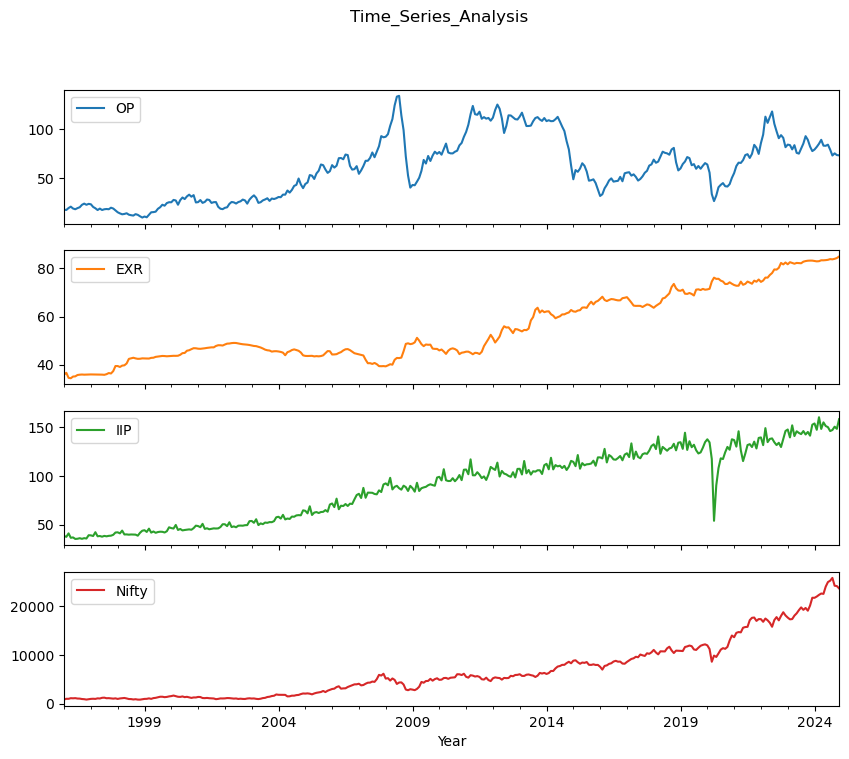

In [25]:
df.plot(subplots = True , figsize = (10,8) , title = 'Time_Series_Analysis') 

In [27]:
df_log  = np.log(df).dropna()

In [33]:
df_diff = df_log.diff().dropna()

array([<Axes: xlabel='Year'>, <Axes: xlabel='Year'>,
       <Axes: xlabel='Year'>, <Axes: xlabel='Year'>], dtype=object)

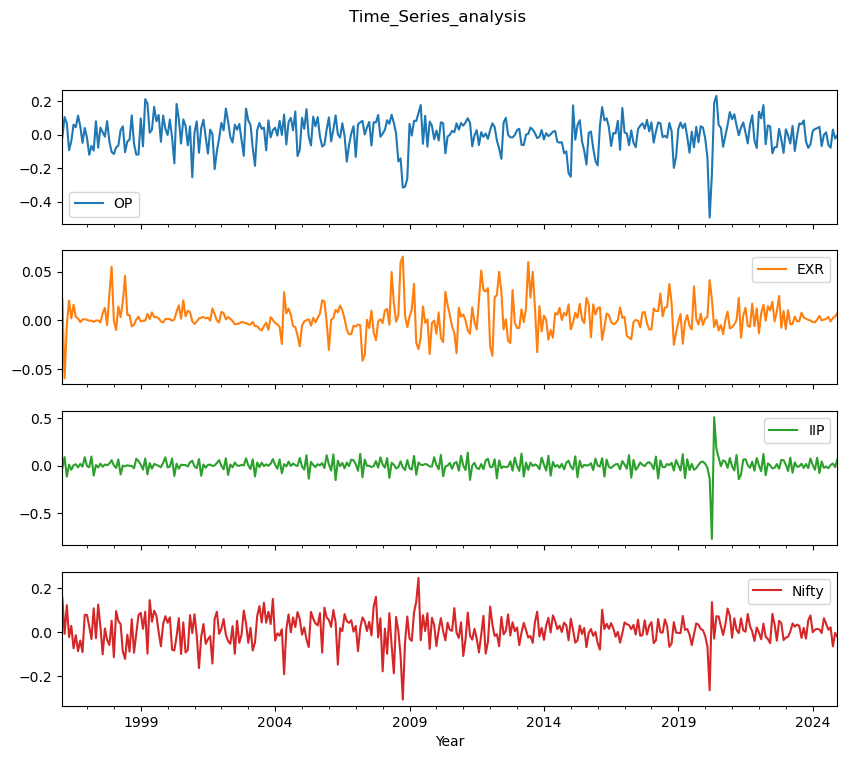

In [35]:
df_diff.plot( subplots = True , figsize = (10,8) , title = 'Time_Series_analysis')

In [81]:
tst = df_diff.apply(lambda x : adfuller(x))
print(tst)

                                                  OP  \
0                                          -2.145335   
1                                            0.22668   
2                                                  1   
3                                                346   
4  {'1%': -3.4493918438232525, '5%': -2.869929801...   
5                                        -667.452076   

                                                 EXR  \
0                                          -0.662324   
1                                           0.856269   
2                                                  5   
3                                                342   
4  {'1%': -3.4496162602188187, '5%': -2.870028369...   
5                                       -1844.909736   

                                                 IIP  \
0                                          -1.450034   
1                                           0.558068   
2                                             

In [41]:
from statsmodels.tsa.api import VAR

In [71]:
model = VAR(df)

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [73]:
lg_sel =  model.select_order(maxlags = 12)
print(lg_sel.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        32.24       32.28   1.002e+14       32.26
1        18.63       18.86   1.235e+08       18.72
2        18.28      18.69*   8.694e+07      18.44*
3        18.29       18.88   8.780e+07       18.53
4        18.32       19.10   9.089e+07       18.63
5        18.34       19.30   9.271e+07       18.72
6        18.35       19.49   9.342e+07       18.80
7        18.33       19.65   9.150e+07       18.86
8        18.35       19.85   9.299e+07       18.94
9        18.32       20.00   9.069e+07       18.99
10       18.31       20.17   8.971e+07       19.05
11       18.36       20.40   9.444e+07       19.17
12      18.06*       20.29  7.040e+07*       18.95
--------------------------------------------------


In [85]:
johan_tst = coint_johansen(df , det_order = 0 , k_ar_diff = 2)
print("\nJohansen Test Trace Statistics:")
print(johan_tst.lr1)
print("\nCritical values (90% , 95% , 99%):")
print(johan_tst.cvt)


Johansen Test Trace Statistics:
[51.84683054 23.72855325 11.45699998  1.53345595]

Critical values (90% , 95% , 99%):
[[44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [91]:
vecm = VECM(endog = df , k_ar_diff = 2 , coint_rank = 1 , deterministic = 'co')
vecm_res = vecm.fit()
print(vecm_res.summary())

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation OP
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1663      1.441      3.585      0.000       2.342       7.991
L1.OP          0.3403      0.054      6.328      0.000       0.235       0.446
L1.EXR        -0.2032      0.364     -0.558      0.577      -0.917       0.511
L1.IIP        -0.0693      0.045     -1.527      0.127      -0.158       0.020
L1.Nifty       0.0016      0.001      2.325      0.020       0.000       0.003
L2.OP         -0.0186      0.054     -0.347      0.729      -0.124       0.086
L2.EXR        -0.1449      0.354     -0.409      0.682      -0.839       0.549
L2.IIP        -0.0692      0.042     -1.630      0.103      -0.152       0.014
L2.Nifty      -0.0002      0.001     -0.224      0.823      -0.002       0.001
Det. terms outside the coint. relation & lagged e

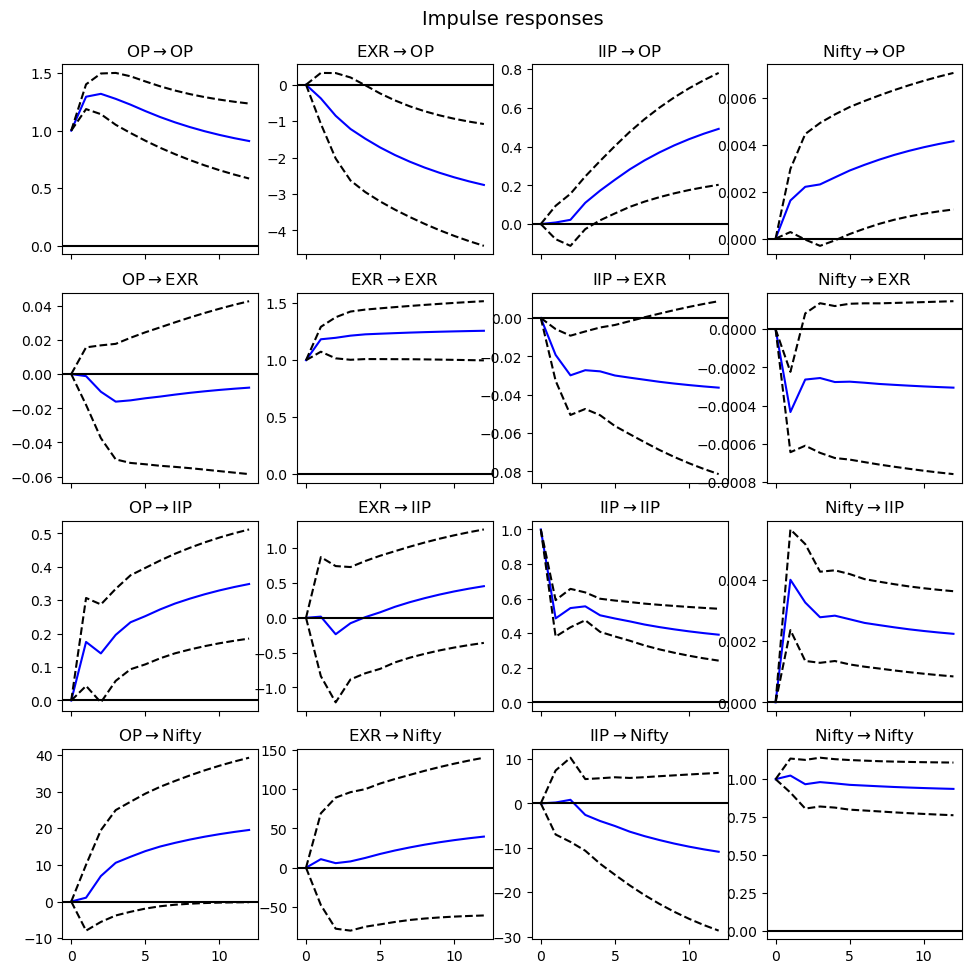

In [99]:
vecm_irf = vecm_res.irf(12)
vecm_irf.plot(orth = False)
plt.show()
